# Compare runs

Loads training histories and saved evaluation results for two or more runs and shows them side by side.

- Training curves come from `logs/<run>/history.json`.
- Comparison table comes from `logs/<run>/config.json` and `artifacts/<run>/evaluation.json`.

Per-run evaluation files are produced by `python -m src.evaluation.evaluate_run <run-name>`.

In [1]:
import sys
from pathlib import Path

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src.evaluation.comparison import (
    format_comparison_markdown,
    load_run_summary,
)
from src.evaluation.training_curves import (
    TRAIN_COLOR,
    VAL_COLOR,
    load_history,
)

## Pick runs to compare

Edit `RUNS` to include any run that has both a `logs/<run>/history.json` and an `artifacts/<run>/evaluation.json`.

In [2]:
RUNS = ['baseline', 'improved_v1']
METRICS = ('loss', 'mae')

## Training curves

Each column is one run; each row is one metric. Train and validation curves are overlaid per cell. Loss values across runs are not necessarily directly comparable (e.g. coordinate-MSE vs heatmap-MSE), but the shape of convergence is.

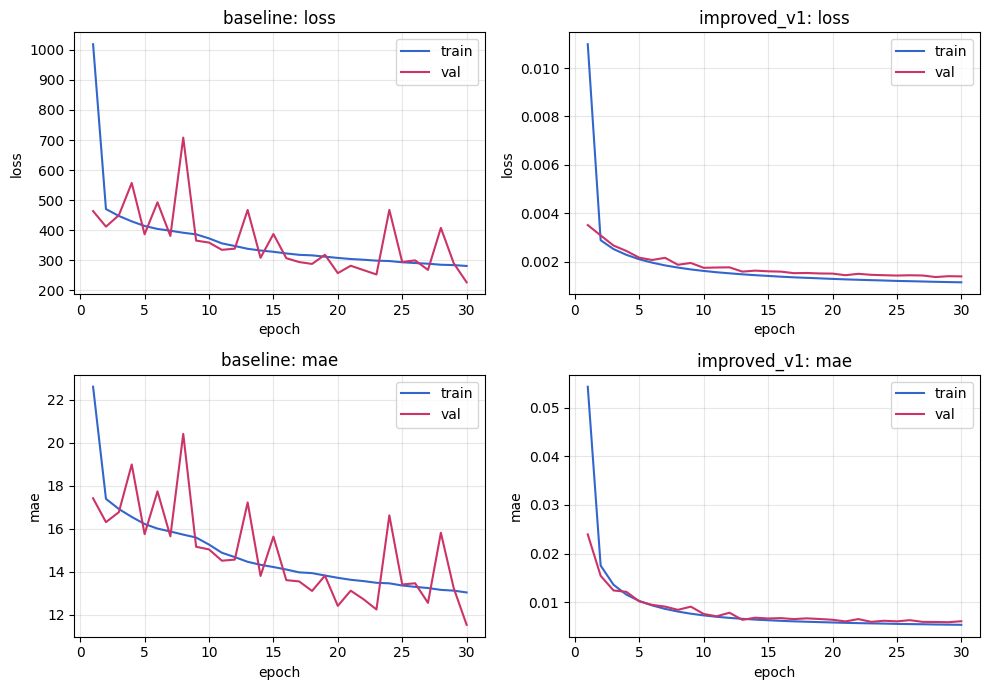

In [3]:
histories = {run: load_history(run) for run in RUNS}

n_rows = len(METRICS)
n_cols = len(RUNS)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.0 * n_cols, 3.5 * n_rows),
    squeeze=False,
)

for col, run in enumerate(RUNS):
    history = histories[run]
    for row, metric in enumerate(METRICS):
        ax = axes[row, col]
        train = history.get(metric)
        val = history.get(f'val_{metric}')
        if train:
            ax.plot(range(1, 1 + len(train)), train, label='train', color=TRAIN_COLOR)
        if val:
            ax.plot(range(1, 1 + len(val)), val, label='val', color=VAL_COLOR)
        ax.set_xlabel('epoch')
        ax.set_ylabel(metric)
        ax.set_title(f'{run}: {metric}')
        ax.grid(True, alpha=0.3)
        if train or val:
            ax.legend()

fig.tight_layout()
plt.show()

## Comparison table

In [4]:
summaries = [load_run_summary(run) for run in RUNS]
display(Markdown(format_comparison_markdown(summaries)))

| Run         | Model                | Repr.      | Params  | MPKE (px) | Median (px) | p90 (px) | p95 (px) | Max (px) |
| ----------- | -------------------- | ---------- | ------- | --------- | ----------- | -------- | -------- | -------- |
| baseline    | baseline_cnn         | coordinate | 137,962 | 18.10     | 17.22       | 26.32    | 30.06    | 75.99    |
| improved_v1 | residual_heatmap_cnn | heatmap    | 754,229 | 8.59      | 7.43        | 14.30    | 17.36    | 52.44    |